## **QUANTUM SPLIT OPERATOR FOURIER TRANSFORM METHOD**

contoh pada sistem DNA Tautomerization

In [1]:
!pip install qiskit --quiet
!pip install qiskit_ibm_runtime --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Batch

In [2]:
#1D PES for A-T tautomerization
d = 6       #number of points#number of qubit
mass = 1    #mass of the particle
xMin = -5
xMax = -xMin
x = np.linspace(xMin, xMax, num=2**d) #position grid
VV = (0.429*x - 1.126*x**2 - 0.143*x**3 + 0.563*x**4) * 0.1

In [3]:
#inisialisasi gaussian wavepacket on a grid
mu = 1
alpha = 1
psi = (alpha/np.pi)**0.25 * np.exp(-alpha *(x-mu)**2 * 0.5)
psi/= np.sqrt(np.sum(np.abs(psi)**2))   #normalisasi

In [6]:
#preparation of potensial and kinetic split propagation
dx = (xMax-xMin)/(2**d-1)

#KE opertaor
dp = 2*np.pi/(xMax-xMin)
N = 2**d
p= np.zeros(N, dtype=float)

for i in range(N):
    p[i] = dp * (i-N/2)

p = np.fft.fftshift(p)
time_step = 0.01

VVd_prop = np.diag(np.exp(-1j*VV*time_step))    #potential propagator
KED_prop = np.diag(np.exp(-1j*p**2/2/mass*time_step))  #kinetic propagator

In [8]:
#quanutm SOFT circuit preparation
from qiskit.circuit.library import QFT

#inisialisasi circuit kosong
nqubits = d
q_reg = QuantumRegister(nqubits)
c_reg = ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg, c_reg)

qc.initialize(psi, q_reg[:])

for k in range(600):
    bound_op = Operator(VVd_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)
    bound_op = Operator(KED_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)

/tmp/ipykernel_969555/2752036018.py:15: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)
/tmp/ipykernel_969555/2752036018.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)


In [10]:
#quantum soft circuit execution
from qiskit import transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator(method='statevector')
qc.save_statevector()

qc_transpiled = transpile(qc, simulator)
psin = simulator.run(qc_transpiled).result().get_statevector()
print(psin)

Statevector([-1.25103541e-05-8.22560466e-06j,
             -3.81982290e-08-2.72873335e-05j,
              3.92830873e-06-4.54269467e-05j,
              4.14545444e-05-1.10845450e-04j,
              1.08624432e-04-2.28853822e-04j,
              2.25362515e-04-4.42267745e-04j,
              4.08099570e-04-8.11471396e-04j,
              6.81152664e-04-1.40541027e-03j,
              1.02336808e-03-2.28973478e-03j,
              1.45776299e-03-3.62142563e-03j,
              2.05522821e-03-5.72982331e-03j,
              2.99902048e-03-9.07196482e-03j,
              4.57669370e-03-1.43431868e-02j,
              7.20796698e-03-2.23233809e-02j,
              1.13370664e-02-3.37692403e-02j,
              1.73236503e-02-4.91988112e-02j,
              2.52484333e-02-6.86552413e-02j,
              3.49264141e-02-9.16813393e-02j,
              4.60030137e-02-1.17270665e-01j,
              5.81075850e-02-1.43951747e-01j,
              7.10491829e-02-1.69998712e-01j,
              8.47696471e-02-1.936

In [11]:
#classical soft benchmark
def soft(fxy, emat, Pxy):
    #soft propagation
    out = emat*fxy
    fp = np.fft.fft(out)*Pxy
    out = np.fft.ifft(fp)
    return out

psi_c_init = psi
psi_c = psi_c_init
iteratons = 600

for i in range(iteratons):
    psi_c = soft(psi_c, np.diag(VVd_prop), np.diag(KED_prop))

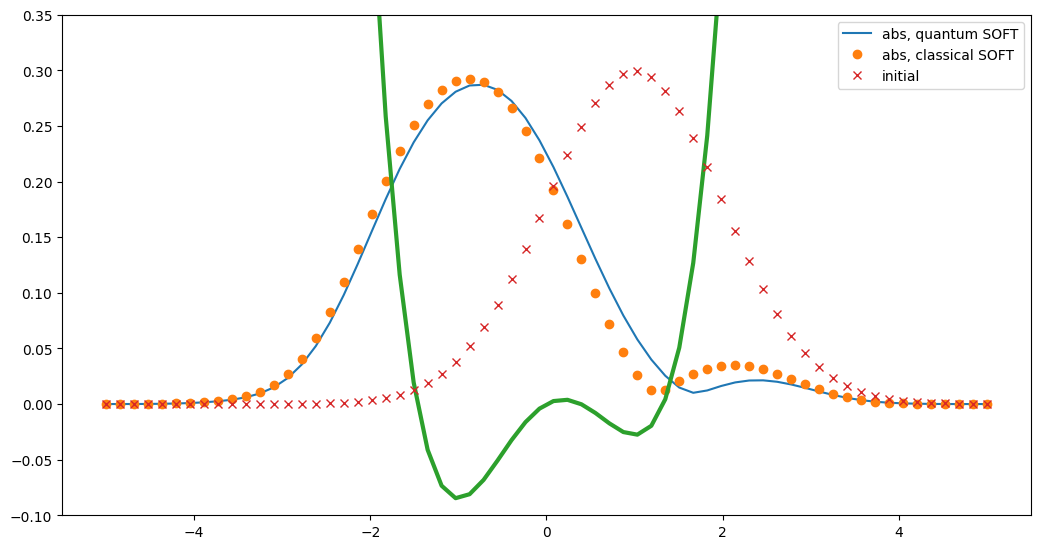

In [15]:
#plotting initial and final wavefunction
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x, np.real(psin), label = 'real')
#plt.plot(x, np.imag(psin), label = 'imag')
plt.plot(x, np.abs(psin), label='abs, quantum SOFT')
plt.plot(x, np.abs(psi_c), 'o', label='abs, classical SOFT')
plt.plot(x, VV, linewidth=3)
plt.plot(x, abs(psi), 'x', label='initial')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1, 0.35)
plt.show()